In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = ["SHY", "IEI", "IEF"]
start_date = "2024-01-01"

data = yf.download(tickers, start=start_date, auto_adjust=False, progress=False)["Close"]
data = data.dropna().copy()
data.tail()

Ticker,IEF,IEI,SHY
Date,,,
2026-04-24,95.559998,118.690002,82.570000
2026-04-27,95.339996,118.570000,82.550003
2026-04-28,95.250000,118.440002,82.500000
2026-04-29,94.800003,118.040001,82.389999
2026-04-30,94.980003,118.230003,82.480003


In [3]:
data = data.rename(columns={
    "SHY": "short_end",
    "IEI": "belly",
    "IEF": "long_end"
})

data.head()

Ticker,long_end,belly,short_end
Date,,,
2024-01-02,96.029999,116.790001,81.940002
2024-01-03,96.260002,116.949997,81.959999
2024-01-04,95.680000,116.580002,81.910004
2024-01-05,95.330002,116.379997,81.889999
2024-01-08,95.650002,116.620003,81.959999


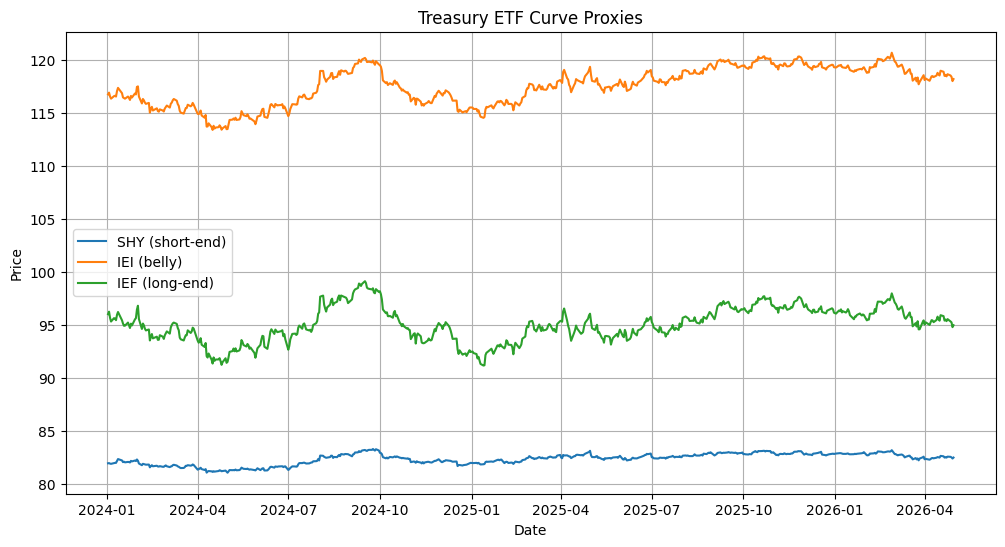

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data["short_end"], label="SHY (short-end)")
plt.plot(data.index, data["belly"], label="IEI (belly)")
plt.plot(data.index, data["long_end"], label="IEF (long-end)")
plt.title("Treasury ETF Curve Proxies")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
data["fly"] = 2 * data["belly"] - data["short_end"] - data["long_end"]
data[["short_end", "belly", "long_end", "fly"]].tail()

Ticker,short_end,belly,long_end,fly
Date,,,,
2026-04-24,82.570000,118.690002,95.559998,59.250008
2026-04-27,82.550003,118.570000,95.339996,59.250000
2026-04-28,82.500000,118.440002,95.250000,59.130005
2026-04-29,82.389999,118.040001,94.800003,58.889999
2026-04-30,82.480003,118.230003,94.980003,59.000000


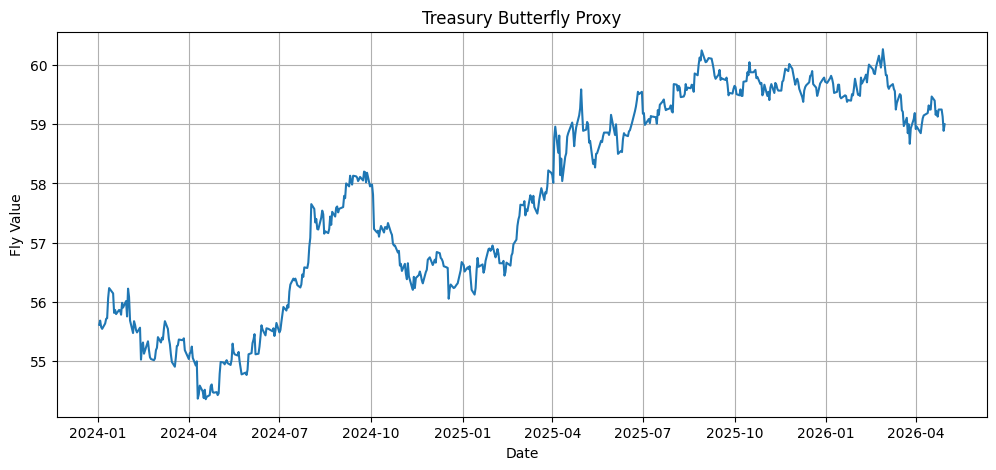

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["fly"])
plt.title("Treasury Butterfly Proxy")
plt.xlabel("Date")
plt.ylabel("Fly Value")
plt.grid(True)
plt.show()

In [7]:
for window in [20, 60, 120]:
    data[f"fly_mean_{window}"] = data["fly"].rolling(window).mean()
    data[f"fly_std_{window}"] = data["fly"].rolling(window).std()
    data[f"fly_zscore_{window}"] = (
        (data["fly"] - data[f"fly_mean_{window}"]) / data[f"fly_std_{window}"]
    )

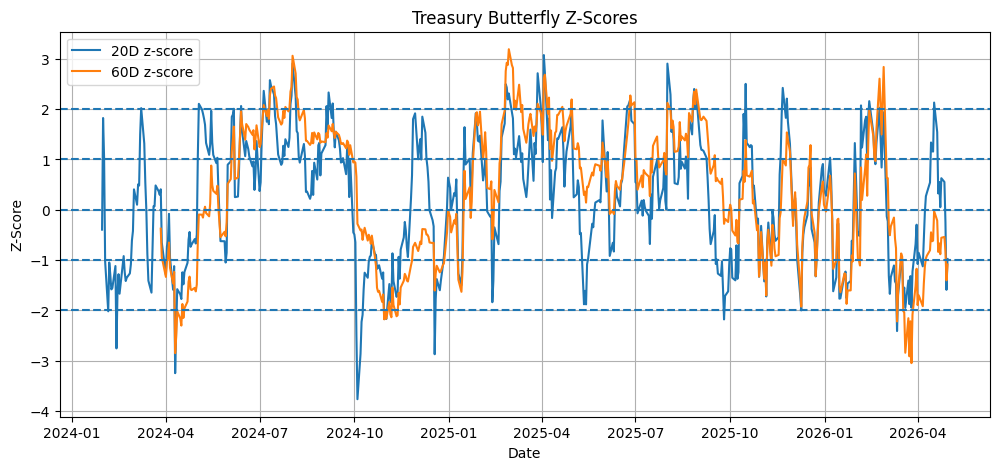

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["fly_zscore_20"], label="20D z-score")
plt.plot(data.index, data["fly_zscore_60"], label="60D z-score")
plt.axhline(0, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Treasury Butterfly Z-Scores")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
latest = data.iloc[-1]

print("Latest fly:", round(latest["fly"], 4))
print("20D fly z-score:", round(latest["fly_zscore_20"], 4))
print("60D fly z-score:", round(latest["fly_zscore_60"], 4))
print("120D fly z-score:", round(latest["fly_zscore_120"], 4))

Latest fly: 59.0
20D fly z-score: -0.9765
60D fly z-score: -1.0862
120D fly z-score: -1.6966


In [10]:
current_fly = latest["fly"]
percentile = (data["fly"] < current_fly).mean() * 100

print("Current fly percentile:", round(percentile, 2), "%")

Current fly percentile: 63.36 %


In [11]:
data["ret_short"] = data["short_end"].pct_change()
data["ret_belly"] = data["belly"].pct_change()
data["ret_long"] = data["long_end"].pct_change()

data["corr_short_belly_20"] = data["ret_short"].rolling(20).corr(data["ret_belly"])
data["corr_belly_long_20"] = data["ret_belly"].rolling(20).corr(data["ret_long"])

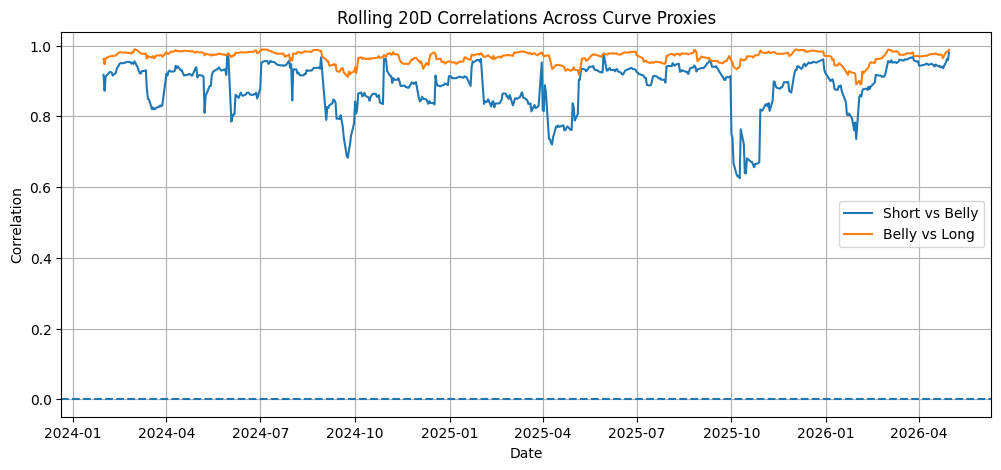

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["corr_short_belly_20"], label="Short vs Belly")
plt.plot(data.index, data["corr_belly_long_20"], label="Belly vs Long")
plt.axhline(0, linestyle="--")
plt.title("Rolling 20D Correlations Across Curve Proxies")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
if latest["fly_zscore_20"] > 1:
    print("The belly looks rich relative to the wings on a short-term basis.")
elif latest["fly_zscore_20"] < -1:
    print("The belly looks cheap relative to the wings on a short-term basis.")
else:
    print("The fly is not especially stretched on a short-term basis.")

The fly is not especially stretched on a short-term basis.


In [14]:
signals = {
    "fly_level": latest["fly"],
    "fly_zscore_20": latest["fly_zscore_20"],
    "fly_zscore_60": latest["fly_zscore_60"],
    "fly_zscore_120": latest["fly_zscore_120"],
    "fly_percentile": percentile,
    "corr_short_belly_20": data["corr_short_belly_20"].dropna().iloc[-1],
    "corr_belly_long_20": data["corr_belly_long_20"].dropna().iloc[-1]
}

signals

{'fly_level': np.float64(59.0),
 'fly_zscore_20': np.float64(-0.976523201251467),
 'fly_zscore_60': np.float64(-1.0861801239248696),
 'fly_zscore_120': np.float64(-1.6965753887226547),
 'fly_percentile': np.float64(63.35616438356164),
 'corr_short_belly_20': np.float64(0.980997037794188),
 'corr_belly_long_20': np.float64(0.9884869924916304)}

## Preliminary pre-trade conclusion

This notebook evaluates whether the current Treasury curve shape is statistically stretched enough to justify a butterfly trade. The key decision variables are:

- whether the butterfly z-score is meaningfully positive or negative
- whether the current fly sits at an extreme percentile
- whether short-, medium-, and longer-window signals agree
- whether the curve proxies remain sufficiently correlated for a relative-value trade to make sense

A butterfly becomes more attractive if the fly is meaningfully stretched and the macro environment supports non-parallel curve repricing. It becomes less attractive if the fly is close to fair value and recent curve dynamics are stable.

In [15]:
if abs(latest["fly_zscore_20"]) > 1.5 or abs(latest["fly_zscore_60"]) > 1.5:
    print("Preliminary signal: Treasury butterfly looks interesting and potentially actionable.")
elif abs(latest["fly_zscore_20"]) > 1.0:
    print("Preliminary signal: Treasury butterfly is somewhat stretched and worth monitoring.")
else:
    print("Preliminary signal: Treasury butterfly does not currently show a strong stretch.")

Preliminary signal: Treasury butterfly does not currently show a strong stretch.
